In [191]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [226]:
df = pd.read_excel("data_extended.xlsx")

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATE                          1000 non-null   datetime64[ns]
 1   DAY                           1000 non-null   int64         
 2   HOLIDAY                       177 non-null    object        
 3   Max Temperature (°F)          1000 non-null   int64         
 4   Min Temperature (°F)          1000 non-null   int64         
 5   Weather                       1000 non-null   object        
 6   DAILY INWARD PASSENGER        1000 non-null   int64         
 7   DAILY OUTWARD PASSENGER       1000 non-null   int64         
 8   Total footfall                1000 non-null   int64         
 9   Reserve passenger orginating  1000 non-null   int64         
 10  Unreserve passenger           1000 non-null   int64         
 11  Avg Detention time per Day    1

In [228]:
df.describe()

,DATE,DAY,Max Temperature (°F),Min Temperature (°F),DAILY INWARD PASSENGER,DAILY OUTWARD PASSENGER,Total footfall,Reserve passenger orginating,Unreserve passenger,Avg Detention time per Day
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,2023-08-19 12:00:00,2.997000,76.962000,67.136000,26545.820000,19422.642000,45968.46200,11622.063000,31978.290000,31.247000
min,2022-04-07 00:00:00,0.000000,61.000000,46.000000,12458.000000,11254.000000,29160.00000,4697.000000,5145.000000,9.000000
25%,2022-12-12 18:00:00,1.000000,69.000000,59.000000,24597.500000,18410.000000,43957.75000,11171.000000,31786.000000,19.000000
50%,2023-08-19 12:00:00,3.000000,78.000000,68.000000,26427.500000,19387.500000,45715.00000,11621.500000,33866.000000,30.000000
75%,2024-04-25 06:00:00,5.000000,85.000000,75.000000,28065.500000,20234.250000,47867.00000,12028.500000,35877.500000,43.000000
max,2024-12-31 00:00:00,6.000000,93.000000,87.000000,69568.000000,56458.000000,110824.00000,19947.000000,50090.000000,57.000000
std,NaN,1.999747,9.071541,9.779322,4391.677677,2486.282366,5913.50824,1077.710049,7513.949012,13.610997


In [229]:
# feature engineering
df['Temperature Difference'] = df['Max Temperature (°F)'] - df['Min Temperature (°F)']
df['Month'] = df['DATE'].dt.month
df['DayOfWeek'] = df['DATE'].dt.dayofweek
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Is_Holiday'] = df['HOLIDAY'].notna().astype(int)
df = pd.get_dummies(data=df,columns=['Weather'])

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   DATE                          1000 non-null   datetime64[ns]
 1   DAY                           1000 non-null   int64         
 2   HOLIDAY                       177 non-null    object        
 3   Max Temperature (°F)          1000 non-null   int64         
 4   Min Temperature (°F)          1000 non-null   int64         
 5   DAILY INWARD PASSENGER        1000 non-null   int64         
 6   DAILY OUTWARD PASSENGER       1000 non-null   int64         
 7   Total footfall                1000 non-null   int64         
 8   Reserve passenger orginating  1000 non-null   int64         
 9   Unreserve passenger           1000 non-null   int64         
 10  Avg Detention time per Day    1000 non-null   int64         
 11  Temperature Difference        1

In [231]:
df.columns

Index(['DATE', 'DAY', 'HOLIDAY', 'Max Temperature (°F)',
       'Min Temperature (°F)', 'DAILY INWARD PASSENGER',
       'DAILY OUTWARD PASSENGER', 'Total footfall',
       'Reserve passenger orginating', 'Unreserve passenger',
       'Avg Detention time per Day', 'Temperature Difference', 'Month',
       'DayOfWeek', 'Is_Weekend', 'Is_Holiday', 'Weather_Cloudy',
       'Weather_Partly Cloudy', 'Weather_Rain', 'Weather_Sunny'],
      dtype='object')

In [232]:
df.drop(columns=['HOLIDAY'],inplace=True)

In [233]:
df.columns

Index(['DATE', 'DAY', 'Max Temperature (°F)', 'Min Temperature (°F)',
       'DAILY INWARD PASSENGER', 'DAILY OUTWARD PASSENGER', 'Total footfall',
       'Reserve passenger orginating', 'Unreserve passenger',
       'Avg Detention time per Day', 'Temperature Difference', 'Month',
       'DayOfWeek', 'Is_Weekend', 'Is_Holiday', 'Weather_Cloudy',
       'Weather_Partly Cloudy', 'Weather_Rain', 'Weather_Sunny'],
      dtype='object')

In [234]:
sns.set_style("whitegrid")

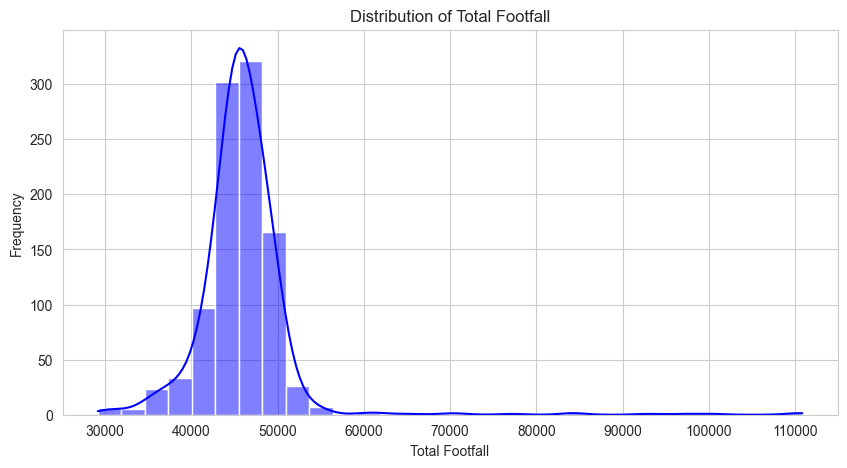

In [235]:
## 3.1 Distribution of Total Footfall
plt.figure(figsize=(10,5))
sns.histplot(df['Total footfall'], bins=30, kde=True, color='blue')
plt.title('Distribution of Total Footfall')
plt.xlabel('Total Footfall')
plt.ylabel('Frequency')
plt.show()

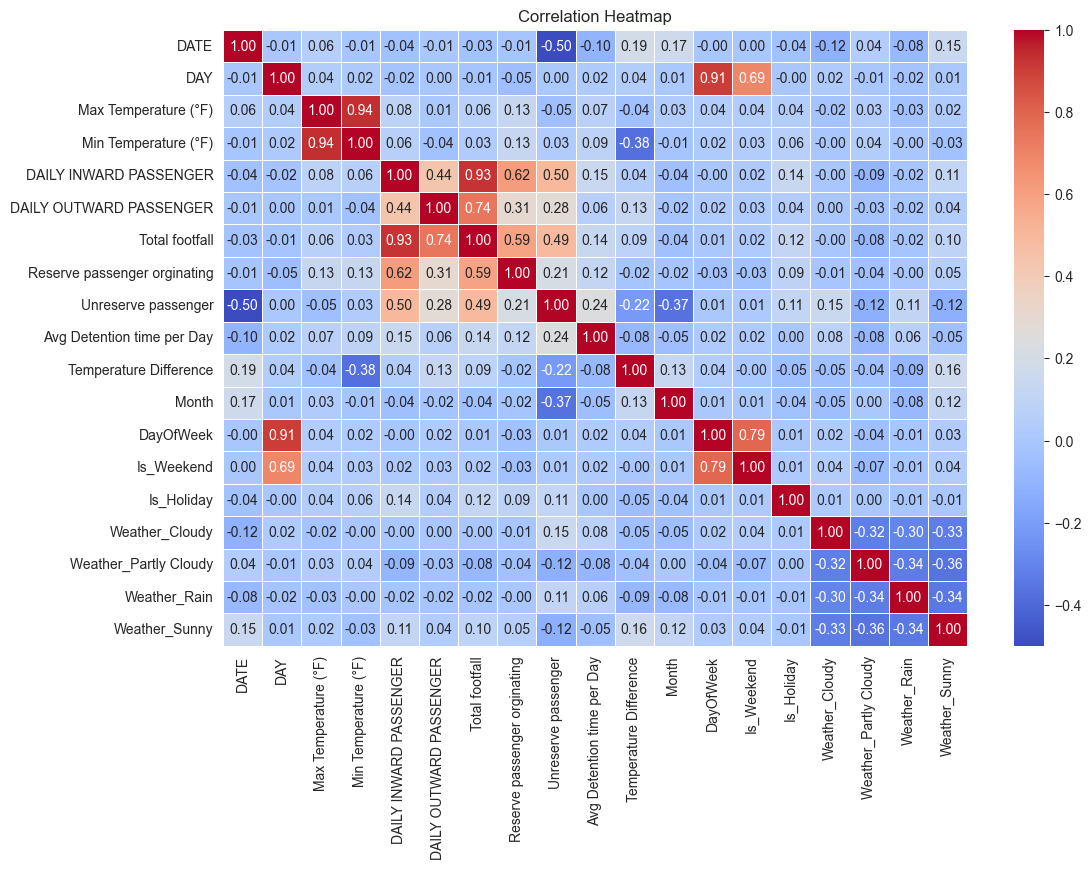

In [236]:
## 3.2 Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<Figure size 1400x1000 with 0 Axes>

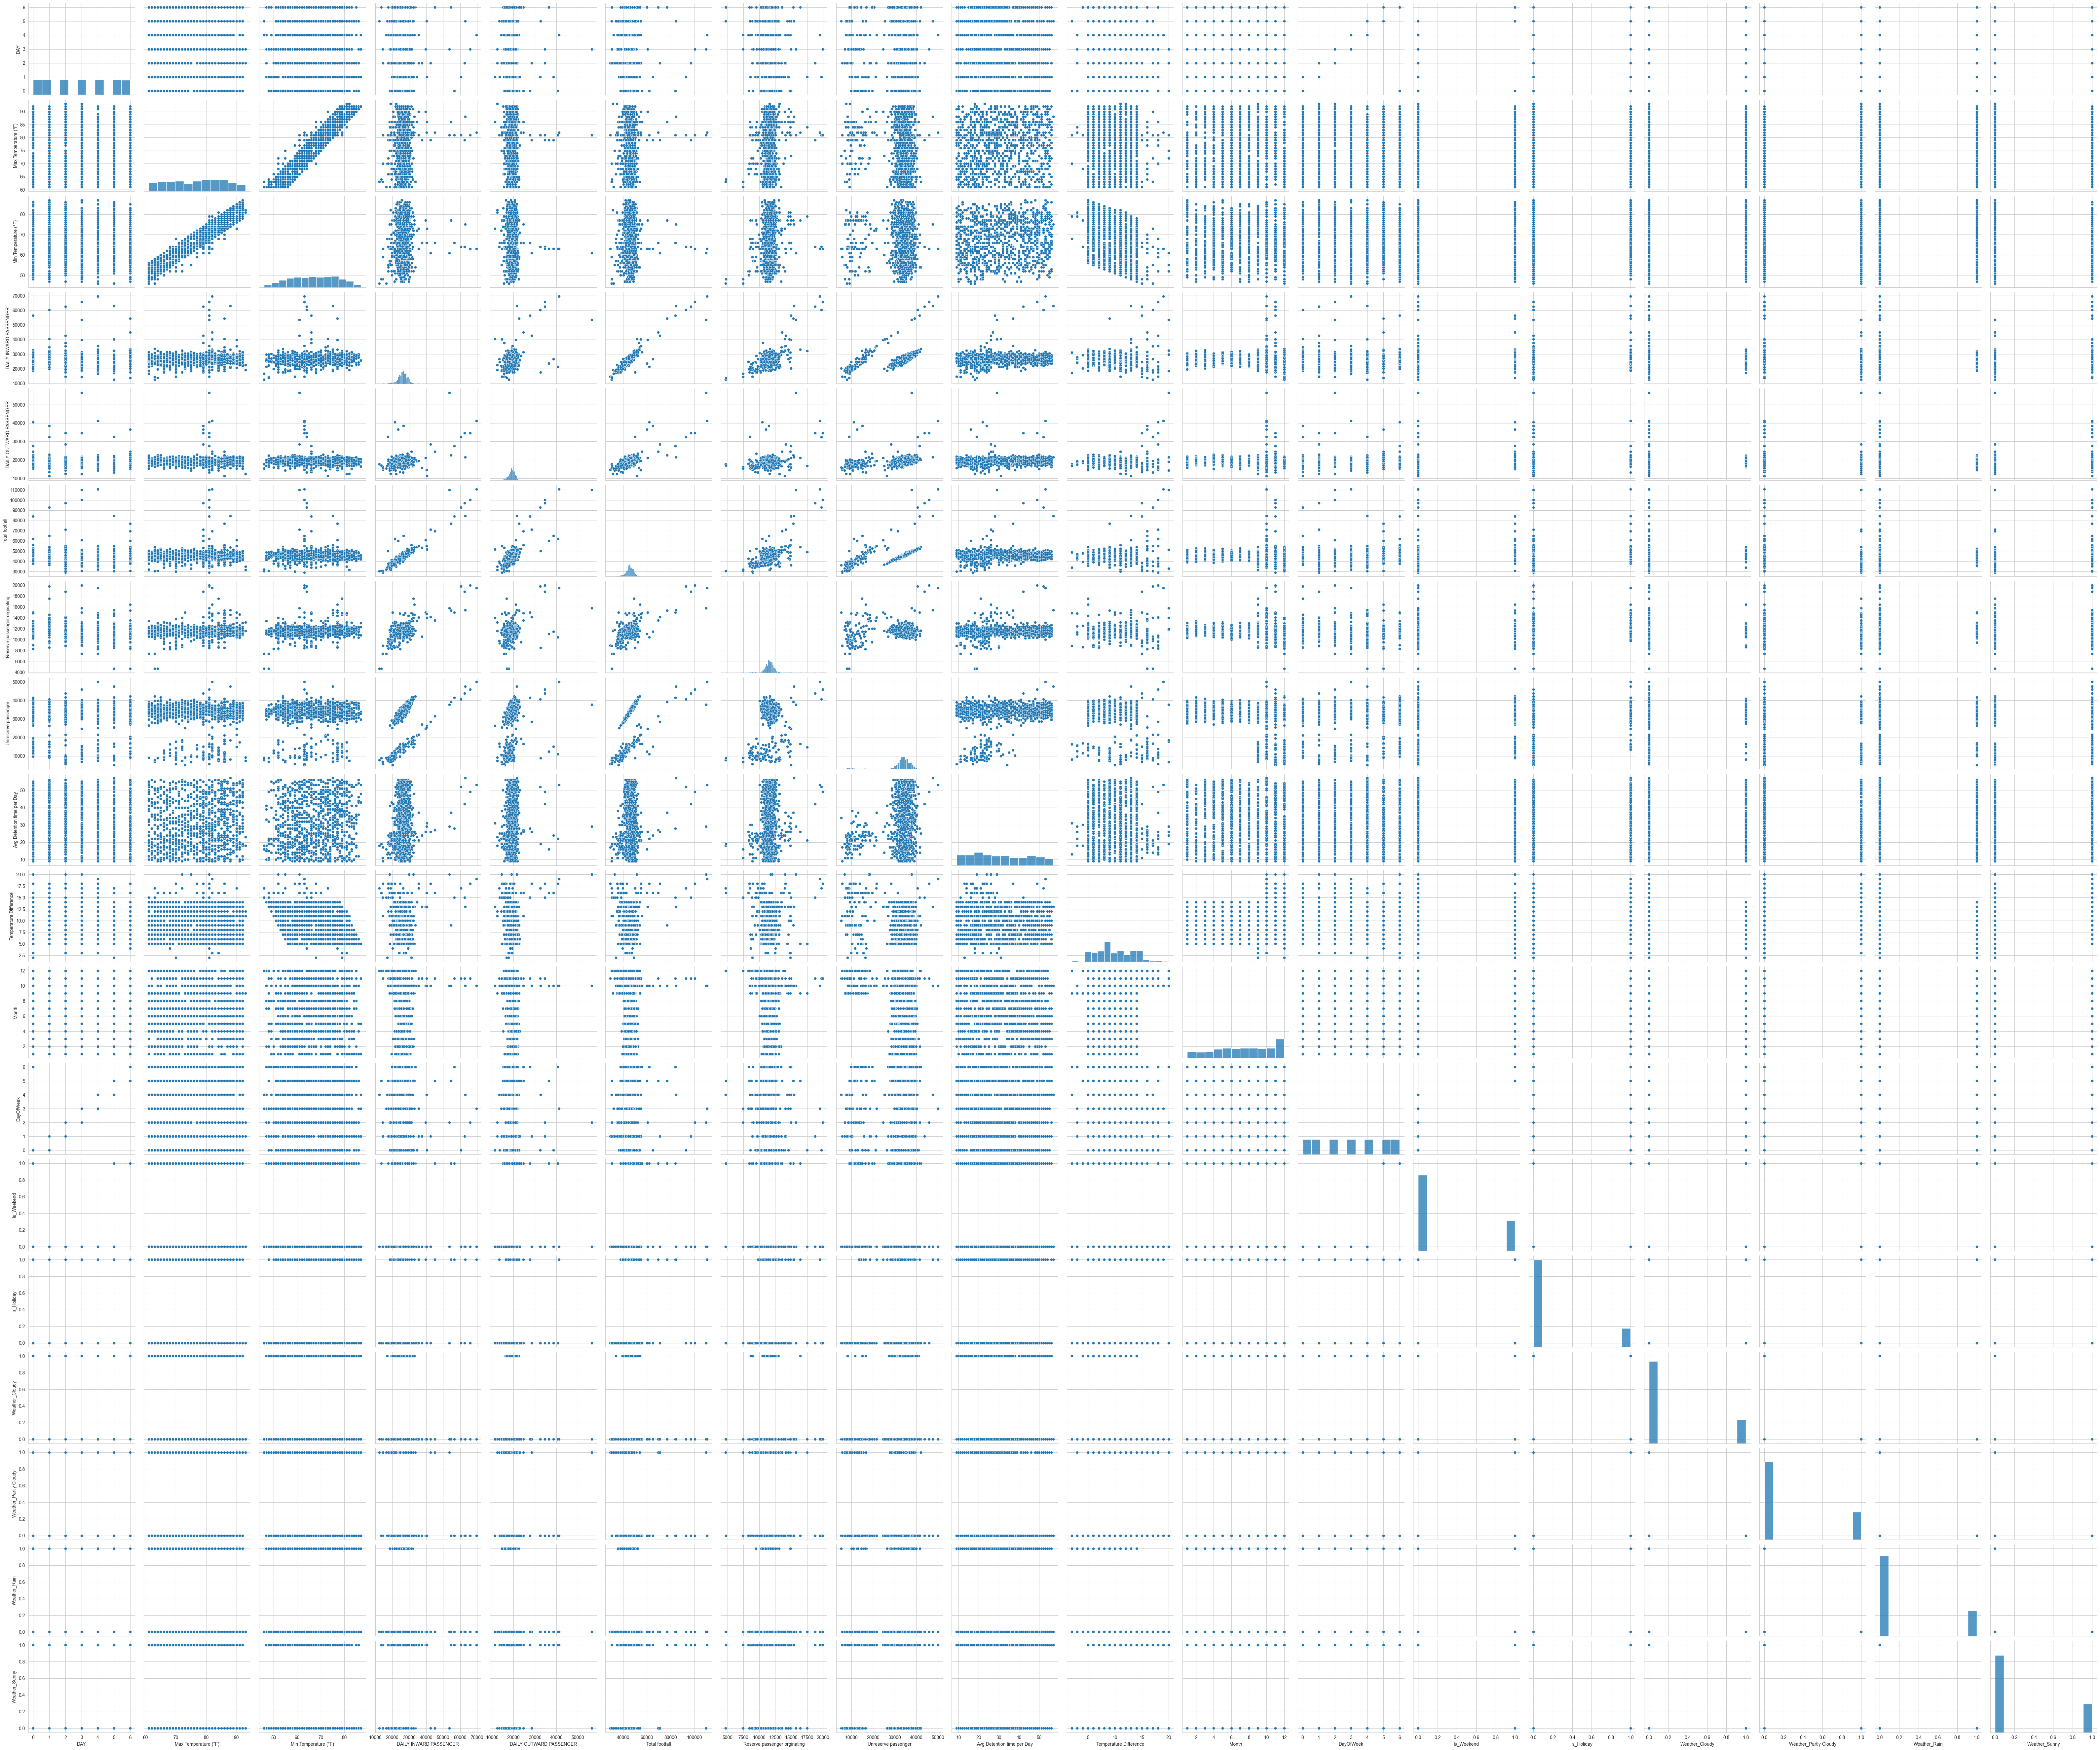

In [237]:
plt.figure(figsize=(14,10))  # This line is not needed for pairplot
sns.pairplot(data=df, height=3, aspect=1.2)  # Increase plot size
plt.show()

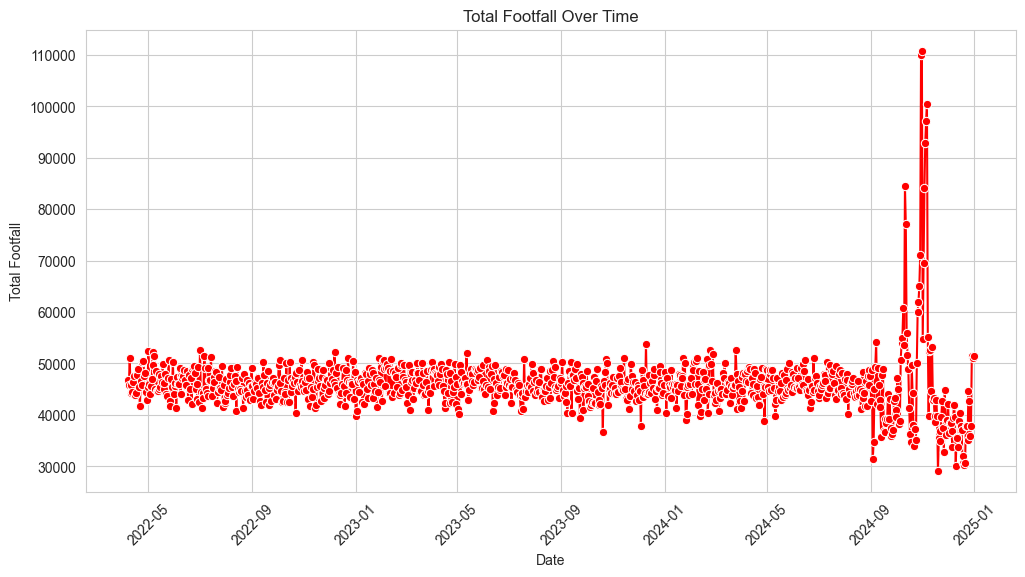

In [238]:
plt.figure(figsize=(12,6))
sns.lineplot(x=df['DATE'], y=df['Total footfall'], marker="o", color="red")
plt.title("Total Footfall Over Time")
plt.xlabel("Date")
plt.ylabel("Total Footfall")
plt.xticks(rotation=45)
plt.show()

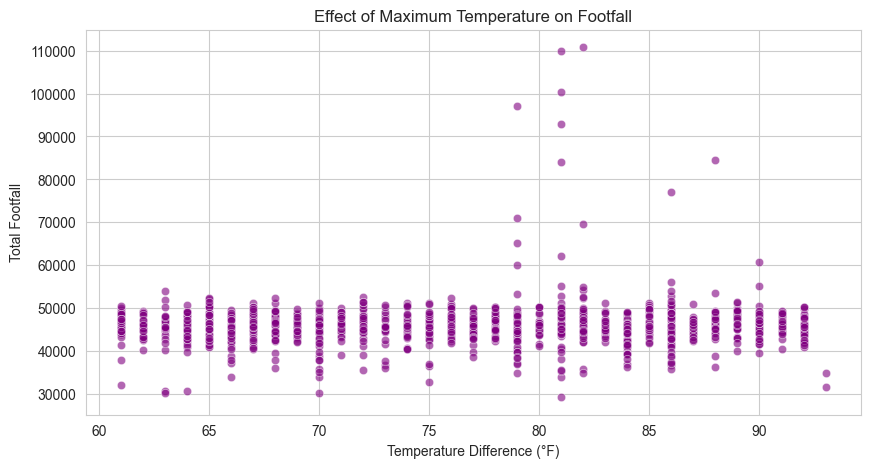

In [239]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Max Temperature (°F)'], y=df['Total footfall'], alpha=0.6, color='purple')
plt.title("Effect of Maximum Temperature on Footfall")
plt.xlabel("Temperature Difference (°F)")
plt.ylabel("Total Footfall")
plt.show()

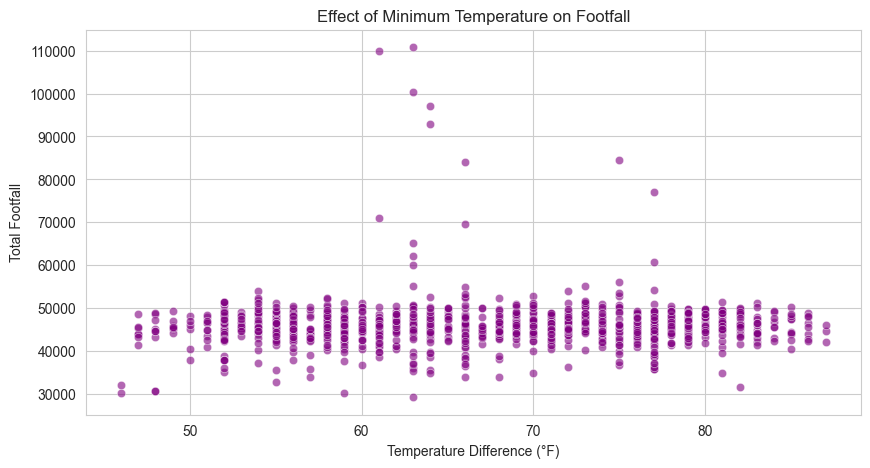

In [240]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Min Temperature (°F)'], y=df['Total footfall'], alpha=0.6, color='purple')
plt.title("Effect of Minimum Temperature on Footfall")
plt.xlabel("Temperature Difference (°F)")
plt.ylabel("Total Footfall")
plt.show()

C:\Users\hp8cg\AppData\Local\Temp\ipykernel_13768\272694067.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['Is_Holiday'], y=df['Total footfall'], estimator=np.mean, palette="coolwarm")


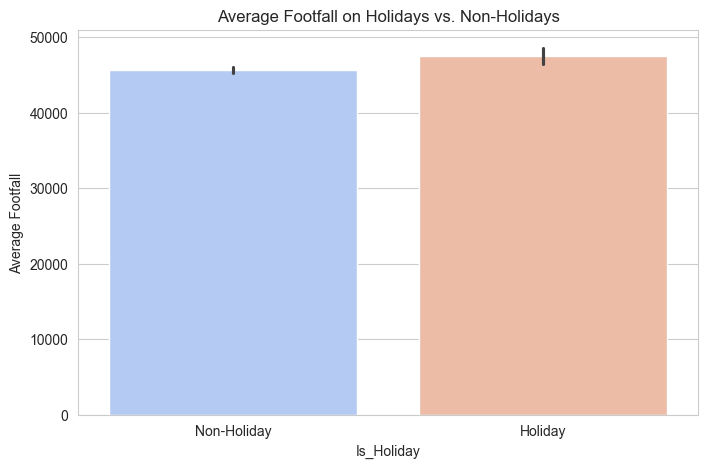

In [241]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['Is_Holiday'], y=df['Total footfall'], estimator=np.mean, palette="coolwarm")
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
plt.title("Average Footfall on Holidays vs. Non-Holidays")
plt.ylabel("Average Footfall")
plt.show()

C:\Users\hp8cg\AppData\Local\Temp\ipykernel_13768\2629476822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df[['Weather_Cloudy', 'Weather_Partly Cloudy', 'Weather_Rain', 'Weather_Sunny']].idxmax(axis=1),


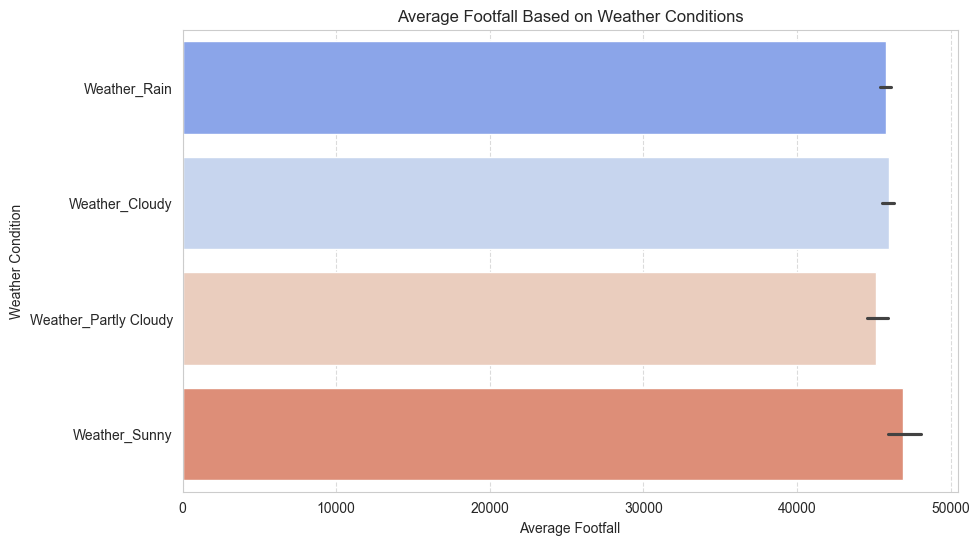

In [242]:
plt.figure(figsize=(10,6))
sns.barplot(y=df[['Weather_Cloudy', 'Weather_Partly Cloudy', 'Weather_Rain', 'Weather_Sunny']].idxmax(axis=1), 
            x=df['Total footfall'], estimator=np.mean, palette="coolwarm")
plt.title("Average Footfall Based on Weather Conditions")
plt.xlabel("Average Footfall")
plt.ylabel("Weather Condition")
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Light grid for reference
plt.show()

In [243]:
df.columns

Index(['DATE', 'DAY', 'Max Temperature (°F)', 'Min Temperature (°F)',
       'DAILY INWARD PASSENGER', 'DAILY OUTWARD PASSENGER', 'Total footfall',
       'Reserve passenger orginating', 'Unreserve passenger',
       'Avg Detention time per Day', 'Temperature Difference', 'Month',
       'DayOfWeek', 'Is_Weekend', 'Is_Holiday', 'Weather_Cloudy',
       'Weather_Partly Cloudy', 'Weather_Rain', 'Weather_Sunny'],
      dtype='object')

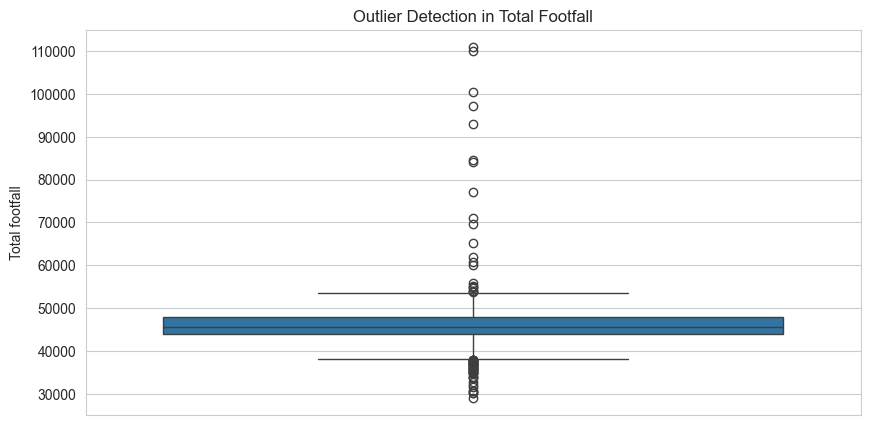

In [244]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(df['Total footfall'])
plt.title("Outlier Detection in Total Footfall")
plt.show()

In [245]:
Q1 = df['Total footfall'].quantile(0.25)
Q3 = df['Total footfall'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Total footfall'] >= lower_bound) & (df['Total footfall'] <= upper_bound)]

In [246]:
df.shape

(937, 19)

In [247]:
X = df[['Max Temperature (°F)', 'Min Temperature (°F)', 'Month', 'DayOfWeek', 
        'Is_Weekend', 'Weather_Cloudy', 'Weather_Partly Cloudy', 'Weather_Rain', 
        'Weather_Sunny', 'Is_Holiday']]
y = df['Total footfall']

In [248]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [249]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [250]:
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))  # Reshape required
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [251]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  
    Dense(32),
    LeakyReLU(alpha=0.01),
    Dropout(0.2),  # Dropout layer added
    Dense(16),
    LeakyReLU(alpha=0.01),
    Dense(1, activation='linear')  
])

C:\Users\hp8cg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\hp8cg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [252]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=0.001)  # Learning rate adjust
model.compile(loss='mae', optimizer=optimizer, metrics=['mae'])

In [253]:
history = model.fit(X_train_scaled, y_train_scaled, validation_data=(X_test_scaled, y_test_scaled), epochs=100, batch_size=16)


Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3627 - mae: 0.3627 - val_loss: 0.1674 - val_mae: 0.1674
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1736 - mae: 0.1736 - val_loss: 0.1628 - val_mae: 0.1628
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1633 - mae: 0.1633 - val_loss: 0.1459 - val_mae: 0.1459
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1675 - mae: 0.1675 - val_loss: 0.1468 - val_mae: 0.1468
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1600 - mae: 0.1600 - val_loss: 0.1483 - val_mae: 0.1483
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1562 - mae: 0.1562 - val_loss: 0.1485 - val_mae: 0.1485
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1534 - mae: 0.1534 - val_loss: 0.1470 - val_mae: 0.1470
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1593 - mae: 0.1593 - val_loss: 0.1509 - val_mae: 0.1509
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.148

In [254]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_scaled)
print(f"Test Loss: {test_loss}, Test MAE: {test_mae}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1542 - mae: 0.1542 
Test Loss: 0.15423013269901276, Test MAE: 0.15423013269901276


In [255]:
original_mae = scaler_y.inverse_transform([[test_mae]])[0][0]  
print(f"Original MAE: {original_mae}")


Original MAE: 40405.04343904555
